In [1]:
# Cell 1: Setup and Imports
import sys
import os
import logging

# Configure notebook logging to show INFO messages
logging.basicConfig(
    level=logging.DEBUG, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S"
)

# Add Scripts directory to path
current_dir = os.getcwd()
scripts_path = os.path.join(current_dir, "Scripts")
if scripts_path not in sys.path:
    sys.path.append(scripts_path)

from dynawo_notebooks.Scripts.core.mo_topology import MoTopologyToolkit
from IPython.display import SVG, display

# Configurations
SOURCE_DIR = "Models"
MODEL_NAME = "Dynawo.Examples.Nordic.Grid.FullStaticModel"
DYNAWO_PKG = "/home/guiu/Projects/Dynawo/nightly/dynawo/ddb/Dynawo/package.mo"
LOCAL_FILES = ["FullStaticModel.mo"]

print("Toolkit loaded.")

Toolkit loaded.


In [2]:
# Cell 2: Extraction and Parsing
try:
    # Instantiate the Toolkit (Facade)
    toolkit = MoTopologyToolkit(SOURCE_DIR, MODEL_NAME, DYNAWO_PKG, LOCAL_FILES)

    # Execute Parsing Pipeline
    parsed_data = toolkit.parse_electrical_data()

    # Export for verification
    toolkit.export_to_standard_json(parsed_data, "grid_export.json")

    print(f"Parsing successful. Found {len(parsed_data['generators'])} generators.")

except Exception as e:
    print(f"An error occurred: {e}")

12:17:15 [INFO] ============================================================
12:17:15 [INFO] Initializing MoTopologyToolkit for model: Dynawo.Examples.Nordic.Grid.FullStaticModel
12:17:15 [INFO] ============================================================
12:17:15 [INFO] Connecting to OpenModelica Compiler (OMC)...
12:17:15 [INFO] Local OMC Server is up and running at ZMQ port tcp://127.0.0.1:41515 pid=17719
12:17:15 [INFO] OMC Session established successfully.
12:17:15 [INFO] Loading Standard Modelica Libraries...
12:17:15 [DEBUG] sendExpression('loadModel(Modelica)', parsed=True)
12:17:15 [DEBUG] sendExpression('loadModel(Complex)', parsed=True)
12:17:16 [DEBUG] sendExpression('loadModel(ModelicaServices)', parsed=True)
12:17:16 [INFO] Loading Dynawo Package from: /home/guiu/Projects/Dynawo/nightly/dynawo/ddb/Dynawo/package.mo
12:17:16 [DEBUG] sendExpression('loadFile("/home/guiu/Projects/Dynawo/nightly/dynawo/ddb/Dynawo/package.mo")', parsed=True)
12:17:16 [INFO] Loading local model

Parsing successful. Found 19 generators.


In [3]:
# Cell 3: Build PowSybl Network

network = toolkit.build_powsybl_network(parsed_data)

print("Network constructed successfully.")
print(f"- Buses: {len(network.get_buses())}")
print(f"- Lines: {len(network.get_lines())}")
print(f"- Generators: {len(network.get_generators())}")
print(f"- Loads: {len(network.get_loads())}")
print(f"- Shunts: {len(network.get_shunt_compensators())}")

12:17:25 [INFO] >>> STEP 2: CONVERTING TO POWSYBL
12:17:25 [INFO] Initializing PyPowSybl Network construction...
12:17:25 [DEBUG] Shunt 'shunt_1022': Calculated B=0.00e+00 S from B_pu=0.0 (Sn=100.0 MVA)
12:17:25 [DEBUG] Shunt 'shunt_1041': Calculated B=0.00e+00 S from B_pu=0.0 (Sn=100.0 MVA)
12:17:25 [DEBUG] Shunt 'shunt_1043': Calculated B=0.00e+00 S from B_pu=0.0 (Sn=100.0 MVA)
12:17:25 [DEBUG] Shunt 'shunt_1044': Calculated B=0.00e+00 S from B_pu=0.0 (Sn=100.0 MVA)
12:17:25 [DEBUG] Shunt 'shunt_1045': Calculated B=0.00e+00 S from B_pu=0.0 (Sn=100.0 MVA)
12:17:25 [DEBUG] Shunt 'shunt_4012': Calculated B=0.00e+00 S from B_pu=0.0 (Sn=100.0 MVA)
12:17:25 [DEBUG] Shunt 'shunt_4041': Calculated B=0.00e+00 S from B_pu=0.0 (Sn=100.0 MVA)
12:17:25 [DEBUG] Shunt 'shunt_4043': Calculated B=0.00e+00 S from B_pu=0.0 (Sn=100.0 MVA)
12:17:25 [DEBUG] Shunt 'shunt_4046': Calculated B=0.00e+00 S from B_pu=0.0 (Sn=100.0 MVA)
12:17:25 [DEBUG] Shunt 'shunt_4051': Calculated B=0.00e+00 S from B_pu=0.0 (S

Network constructed successfully.
- Buses: 84
- Lines: 52
- Generators: 19
- Loads: 22
- Shunts: 11


Displaying Network Diagram:


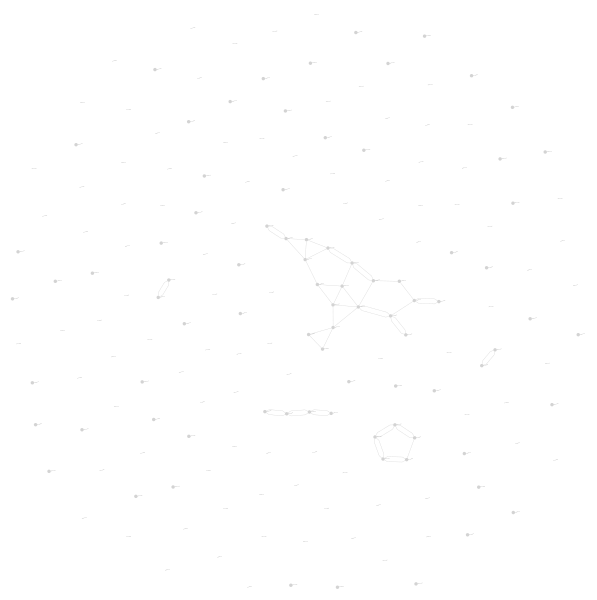

In [4]:
# Cell 4: Visualization
try:
    nad_svg = network.get_network_area_diagram()
    print("Displaying Network Diagram:")
    display(SVG(str(nad_svg)))
except Exception as e:
    print(f"Visualization failed: {e}")